# E-commerce Conversion & Revenue Funnel Analytics

## Business Problem

An e-commerce company receives a large volume of product interactions, but management does not have a clear understanding of how customers move from product discovery to purchase.

The business wants to identify:

- Where customers drop out of the purchase funnel
- Which product categories and brands perform better or worse
- How conversion varies across price segments
- How customer activity and purchasing vary over time
- Which areas represent the greatest revenue opportunity

## Analytical Objective

Analyze the customer journey from:

**Product View → Add to Cart → Purchase**

to identify major funnel bottlenecks, quantify revenue performance, and generate actionable business recommendations.

## Dataset

- Dataset: eCommerce Behavior Data from Multi-Category Store
- Period: October 2019
- Primary unit of funnel analysis: Unique user
- Primary funnel: View → Add to Cart → Purchase

## Tools

- Python
- Pandas
- SQL
- Power BI

## Analytical Dimensions

The analysis covers:

1. Overall funnel performance
2. Revenue performance
3. Product categories
4. Brands
5. Price bands
6. Time-based behavior

## 1. Load and Validate the Production Funnel

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
FUNNEL_FILE = Path("../data/processed/user_funnel.csv")
EDA_DIR = Path("../data/processed/eda")

EDA_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
#Load user_funnel.csv
funnel = pd.read_csv(FUNNEL_FILE)

print("Shape:", funnel.shape)
print("\nColumns:")
print(funnel.columns.tolist())

print("\nData types:")
print(funnel.dtypes)

Shape: (3022290, 9)

Columns:
['user_id', 'viewed', 'added_to_cart', 'purchased', 'first_view_time', 'first_cart_time', 'first_purchase_time', 'purchase_count', 'purchase_revenue']

Data types:
user_id                  int64
viewed                   int64
added_to_cart            int64
purchased                int64
first_view_time         object
first_cart_time         object
first_purchase_time     object
purchase_count           int64
purchase_revenue       float64
dtype: object


In [4]:
funnel.head()

,user_id,viewed,added_to_cart,purchased,first_view_time,first_cart_time,first_purchase_time,purchase_count,purchase_revenue
0,33869381,1,0,0,2019-10-23T20:04:08+00:00,NaN,NaN,0,0.0
1,64078358,1,0,0,2019-10-13T00:13:46+00:00,NaN,NaN,0,0.0
2,183503497,1,0,0,2019-10-02T21:43:00+00:00,NaN,NaN,0,0.0
3,184265397,1,0,0,2019-10-04T17:44:37+00:00,NaN,NaN,0,0.0
4,195082191,1,0,0,2019-10-10T03:35:36+00:00,NaN,NaN,0,0.0


### Production Funnel Validation

Before performing the analysis, the production user-level funnel is checked for:

- Duplicate users
- Missing user IDs
- Invalid funnel hierarchy
- Cart users without a view
- Purchase users without a qualifying cart

In [5]:
#Validate the production funnel
print("Duplicate users:",
      funnel["user_id"].duplicated().sum())

print("Missing user IDs:",
      funnel["user_id"].isna().sum())

print("Cart without view:",
      ((funnel["added_to_cart"] == 1) &
       (funnel["viewed"] == 0)).sum())

print("Purchase without cart:",
      ((funnel["purchased"] == 1) &
       (funnel["added_to_cart"] == 0)).sum())

print("Cart > View:",
      (funnel["added_to_cart"] >
       funnel["viewed"]).sum())

print("Purchase > Cart:",
      (funnel["purchased"] >
       funnel["added_to_cart"]).sum())

Duplicate users: 0
Missing user IDs: 0
Cart without view: 0
Purchase without cart: 0
Cart > View: 0
Purchase > Cart: 0


### Validation Result

The production funnel satisfies the expected hierarchy:

**View ≥ Add to Cart ≥ Purchase**

No duplicate users or invalid funnel relationships were identified.

## 2. Overall Funnel Analysis

### Funnel Construction

The primary funnel is calculated at the **unique-user level** rather than using raw event counts.

This prevents users generating multiple events from being counted multiple times at a funnel stage.

The funnel follows the chronological sequence:

**View → Add to Cart → Purchase**

In [6]:
#Create the overall funnel table
view_users = funnel["viewed"].sum()
cart_users = funnel["added_to_cart"].sum()
purchase_users = funnel["purchased"].sum()

view_to_cart = cart_users / view_users
cart_to_purchase = purchase_users / cart_users
view_to_purchase = purchase_users / view_users

overall_funnel = pd.DataFrame({
    "stage": [
        "View",
        "Add to Cart",
        "Purchase"
    ],
    "users": [
        view_users,
        cart_users,
        purchase_users
    ]
})

overall_funnel

,stage,users
0,View,3022130
1,Add to Cart,336764
2,Purchase,196488


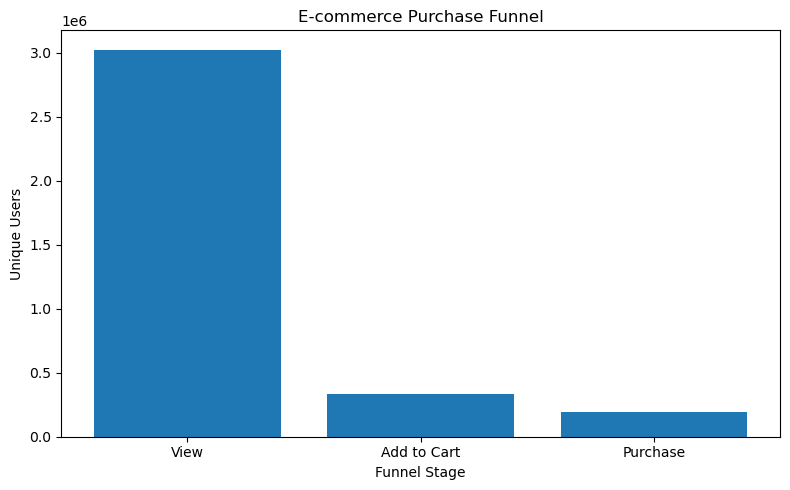

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    overall_funnel["stage"],
    overall_funnel["users"]
)

plt.title("E-commerce Purchase Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Users")

plt.tight_layout()
plt.show()

### Funnel Interpretation

The funnel shows the number of unique users reaching each stage of the customer journey.

The largest user loss occurs between **Product View and Add to Cart**, indicating that the primary opportunity is to improve the transition from product interest to purchase intent.

The Add to Cart → Purchase stage retains a substantially larger proportion of users, suggesting that users who have already added products to their cart are comparatively more likely to complete a purchase.

In [8]:
overall_funnel["conversion_from_previous"] = [
    1,
    view_to_cart,
    cart_to_purchase
]

overall_funnel["overall_conversion"] = [
    1,
    view_to_cart,
    view_to_purchase
]

overall_funnel

,stage,users,conversion_from_previous,overall_conversion
0,View,3022130,1.000000,1.000000
1,Add to Cart,336764,0.111433,0.111433
2,Purchase,196488,0.583459,0.065016


In [9]:
overall_funnel.to_csv(
    EDA_DIR / "overall_funnel.csv",
    index=False
)

## 3. Revenue Analysis

### Revenue Metrics

Revenue metrics are calculated from purchase events recorded in the production user funnel.

Important distinction:

- **Purchase users** = users satisfying the chronological View → Cart → Purchase funnel
- **Purchasing users** = users with at least one purchase event
- **Purchase events** = all recorded purchase events
- **Revenue** = total value of all recorded purchase events

Therefore, purchasing users can exceed funnel purchase users.

In [10]:
#Basic revenue metrics
total_revenue = funnel["purchase_revenue"].sum()
total_purchases = funnel["purchase_count"].sum()

purchasing_users = (
    funnel["purchase_count"] > 0
).sum()

average_revenue_per_purchasing_user = (
    total_revenue / purchasing_users
)

average_revenue_per_purchase_event = (
    total_revenue / total_purchases
)

print(f"Total revenue: ${total_revenue:,.2f}")
print(f"Purchase events: {total_purchases:,}")
print(f"Purchasing users: {purchasing_users:,}")
print(
    f"Revenue per purchasing user: "
    f"${average_revenue_per_purchasing_user:,.2f}"
)
print(
    f"Average purchase value: "
    f"${average_revenue_per_purchase_event:,.2f}"
)

Total revenue: $229,933,212.63
Purchase events: 742,773
Purchasing users: 347,118
Revenue per purchasing user: $662.41
Average purchase value: $309.56


## 4. Category Analysis

Category performance is evaluated using the chronological:

**View Category → Cart Category → Purchase Category**

funnel.

`category_code` is used as the primary category dimension.

Users may interact with multiple categories, therefore category-level user counts should **not be summed to estimate overall unique users**.

In [11]:
category = pd.read_csv(
    "../data/processed/eda/category_analysis.csv"
)

print(category.shape)

print(category.head(10))



(127, 9)
                      category_code  view_users  cart_users  purchase_users  \
0            electronics.smartphone     1300070      198021          120283   
1                           Unknown     1514526       51759           25968   
2                computers.notebook      129207        7462            3834   
3              electronics.video.tv      170044       16641            8786   
4                electronics.clocks      211922        9469            4883   
5         appliances.kitchen.washer      132028        9939            5212   
6  appliances.kitchen.refrigerators      131602        6472            3067   
7       electronics.audio.headphone      213948       22450           11811   
8     appliances.environment.vacuum      119925        8513            4869   
9                electronics.tablet       58730        4091            2200   

   purchase_events       revenue  view_to_cart_rate  cart_to_purchase_rate  \
0           337979  1.570339e+08           

In [12]:
print("Duplicate categories:",
      category["category_code"].duplicated().sum())

print("Missing category labels:",
      category["category_code"].isna().sum())

print("Cart > View:",
      (
          category["cart_users"] >
          category["view_users"]
      ).sum())

print("Purchase > Cart:",
      (
          category["purchase_users"] >
          category["cart_users"]
      ).sum())

print("\nNegative metrics:")
print(
    category[
        [
            "view_users",
            "cart_users",
            "purchase_users",
            "purchase_events",
            "revenue"
        ]
    ].lt(0).sum()
)

Duplicate categories: 0
Missing category labels: 0
Cart > View: 0
Purchase > Cart: 0

Negative metrics:
view_users         0
cart_users         0
purchase_users     0
purchase_events    0
revenue            0
dtype: int64


In [13]:
#Which categories get the most traffic?
category.sort_values(
    "view_users",
    ascending=False
)[
    [
        "category_code",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_purchase_rate"
    ]
].head(10)

,category_code,view_users,cart_users,purchase_users,view_to_purchase_rate
1,Unknown,1514526,51759,25968,0.017146
0,electronics.smartphone,1300070,198021,120283,0.092520
7,electronics.audio.headphone,213948,22450,11811,0.055205
4,electronics.clocks,211922,9469,4883,0.023041
3,electronics.video.tv,170044,16641,8786,0.051669
5,appliances.kitchen.washer,132028,9939,5212,0.039476
6,appliances.kitchen.refrigerators,131602,6472,3067,0.023305
2,computers.notebook,129207,7462,3834,0.029673
18,apparel.shoes,126760,0,0,0.000000
8,appliances.environment.vacuum,119925,8513,4869,0.040600


In [14]:
#Which categories generate the most revenue?
category.sort_values(
    "revenue",
    ascending=False
)[
    [
        "category_code",
        "view_users",
        "cart_users",
        "purchase_users",
        "purchase_events",
        "revenue",
        "view_to_purchase_rate"
    ]
].head(10)

,category_code,view_users,cart_users,purchase_users,purchase_events,revenue,view_to_purchase_rate
0,electronics.smartphone,1300070,198021,120283,337979,1.570339e+08,0.092520
1,Unknown,1514526,51759,25968,173411,2.292217e+07,0.017146
2,computers.notebook,129207,7462,3834,15588,8.978883e+06,0.029673
3,electronics.video.tv,170044,16641,8786,21561,8.422119e+06,0.051669
4,electronics.clocks,211922,9469,4883,17903,4.817089e+06,0.023041
5,appliances.kitchen.washer,132028,9939,5212,16146,4.658223e+06,0.039476
6,appliances.kitchen.refrigerators,131602,6472,3067,11218,3.830077e+06,0.023305
7,electronics.audio.headphone,213948,22450,11811,30501,3.538807e+06,0.055205
8,appliances.environment.vacuum,119925,8513,4869,12378,1.716425e+06,0.040600
9,electronics.tablet,58730,4091,2200,5602,1.610917e+06,0.037460


In [15]:
#Which categories convert best?
category_conversion = category[
    category["view_users"] >= 10_000
].sort_values(
    "view_to_purchase_rate",
    ascending=False
)

category_conversion[
    [
        "category_code",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate"
    ]
].head(10)

,category_code,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,electronics.smartphone,1300070,198021,120283,0.152316,0.607425,0.092520
7,electronics.audio.headphone,213948,22450,11811,0.104932,0.526102,0.055205
3,electronics.video.tv,170044,16641,8786,0.097863,0.527973,0.051669
22,appliances.environment.water_heater,23744,1812,1018,0.076314,0.561810,0.042874
30,appliances.iron,29626,2194,1265,0.074057,0.576572,0.042699
13,computers.peripherals.printer,23785,1797,999,0.075552,0.555927,0.042001
23,appliances.kitchen.microwave,35935,2537,1474,0.070600,0.581001,0.041019
8,appliances.environment.vacuum,119925,8513,4869,0.070986,0.571949,0.040600
5,appliances.kitchen.washer,132028,9939,5212,0.075279,0.524399,0.039476
46,appliances.environment.air_heater,19033,1322,716,0.069458,0.541604,0.037619


In [16]:
#High traffic but weak conversion
high_traffic_categories = category[
    category["view_users"] >= category["view_users"].quantile(0.75)
].sort_values(
    "view_to_purchase_rate"
)

high_traffic_categories[
    [
        "category_code",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_purchase_rate",
        "revenue"
    ]
].head(10)

,category_code,view_users,cart_users,purchase_users,view_to_purchase_rate,revenue
38,apparel.shoes.keds,91620,0,0,0.000000,188218.50
18,apparel.shoes,126760,0,0,0.000000,366486.97
60,apparel.costume,55708,0,0,0.000000,46492.98
14,furniture.living_room.cabinet,53883,0,0,0.000000,452398.40
11,furniture.living_room.sofa,45765,0,0,0.000000,569565.81
20,electronics.audio.subwoofer,50036,214,103,0.002059,300022.08
16,furniture.bedroom.bed,78982,482,234,0.002963,375758.69
66,kids.toys,34668,286,111,0.003202,35968.55
58,accessories.bag,44780,304,144,0.003216,53155.53
33,sport.bicycle,29849,420,124,0.004154,203694.73


## 5. Brand Analysis

Brand-level performance is evaluated across the customer funnel:

**View → Add to Cart → Purchase**

The analysis focuses on:

- Brand traffic
- Funnel conversion
- Purchase volume
- Revenue contribution
- High-traffic brands with weaker conversion

`Unknown` represents events where the original dataset did not provide a brand value.

Brand-level users should not be summed to estimate overall unique users because a user can interact with multiple brands.

In [17]:
# Load production brand analysis
brand = pd.read_csv(
    EDA_DIR / "brand_analysis.csv"
)

print("Shape:", brand.shape)

brand.head()

Shape: (3445, 9)


,brand,view_users,cart_users,purchase_users,purchase_events,revenue,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,apple,729319,81931,46884,142858,1.111995e+08,0.112339,0.572238,0.064285
1,samsung,935464,119305,71858,172878,4.640204e+07,0.127536,0.602305,0.076815
2,xiaomi,470832,43364,22624,56609,9.192640e+06,0.092101,0.521723,0.048051
3,Unknown,980943,9606,4357,58301,8.540682e+06,0.009793,0.453571,0.004442
4,huawei,234061,19014,11334,23499,4.883105e+06,0.081235,0.596087,0.048423


In [18]:
#Production validation
print("Duplicate brands:",
      brand["brand"].duplicated().sum())

print("Missing brand labels:",
      brand["brand"].isna().sum())

print("Cart > View:",
      (
          brand["cart_users"] >
          brand["view_users"]
      ).sum())

print("Purchase > Cart:",
      (
          brand["purchase_users"] >
          brand["cart_users"]
      ).sum())

print("\nNegative metrics:")
print(
    brand[
        [
            "view_users",
            "cart_users",
            "purchase_users",
            "purchase_events",
            "revenue"
        ]
    ].lt(0).sum()
)

Duplicate brands: 0
Missing brand labels: 0
Cart > View: 0
Purchase > Cart: 0

Negative metrics:
view_users         0
cart_users         0
purchase_users     0
purchase_events    0
revenue            0
dtype: int64


In [19]:
#Top brands by traffic
brand.sort_values(
    "view_users",
    ascending=False
)[
    [
        "brand",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_purchase_rate"
    ]
].head(10)

,brand,view_users,cart_users,purchase_users,view_to_purchase_rate
3,Unknown,980943,9606,4357,0.004442
1,samsung,935464,119305,71858,0.076815
0,apple,729319,81931,46884,0.064285
2,xiaomi,470832,43364,22624,0.048051
4,huawei,234061,19014,11334,0.048423
6,lg,145762,6973,3389,0.023250
7,lucente,145492,0,0,0.000000
12,bosch,142152,3867,1802,0.012677
8,sony,122111,5127,2367,0.019384
20,cordiant,119818,3500,1650,0.013771


### Interpretation

The highest-traffic brands represent brands receiving the greatest amount of product-view activity.

Traffic alone does not indicate strong performance, so these brands will also be evaluated using funnel conversion and revenue.

In [20]:
#Top brands by revenue
brand.sort_values(
    "revenue",
    ascending=False
)[
    [
        "brand",
        "view_users",
        "cart_users",
        "purchase_users",
        "purchase_events",
        "revenue",
        "view_to_purchase_rate"
    ]
].head(10)

,brand,view_users,cart_users,purchase_users,purchase_events,revenue,view_to_purchase_rate
0,apple,729319,81931,46884,142858,1.111995e+08,0.064285
1,samsung,935464,119305,71858,172878,4.640204e+07,0.076815
2,xiaomi,470832,43364,22624,56609,9.192640e+06,0.048051
3,Unknown,980943,9606,4357,58301,8.540682e+06,0.004442
4,huawei,234061,19014,11334,23499,4.883105e+06,0.048423
5,acer,87586,4744,2353,6880,3.575716e+06,0.026865
6,lg,145762,6973,3389,8725,3.387361e+06,0.023250
7,lucente,145492,0,0,11576,3.123439e+06,0.000000
8,sony,122111,5127,2367,6729,2.478197e+06,0.019384
9,oppo,114818,9091,5671,10887,2.412034e+06,0.049391


In [21]:
#Best-converting brands
brand_conversion = brand[
    brand["view_users"] >= 10_000
].sort_values(
    "view_to_purchase_rate",
    ascending=False
)

brand_conversion[
    [
        "brand",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate"
    ]
].head(10)

,brand,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
1,samsung,935464,119305,71858,0.127536,0.602305,0.076815
0,apple,729319,81931,46884,0.112339,0.572238,0.064285
9,oppo,114818,9091,5671,0.079177,0.623804,0.049391
4,huawei,234061,19014,11334,0.081235,0.596087,0.048423
2,xiaomi,470832,43364,22624,0.092101,0.521723,0.048051
31,epson,13990,968,555,0.069192,0.573347,0.039671
50,ariston,16573,1136,632,0.068545,0.556338,0.038134
22,vivo,26340,1419,843,0.053872,0.594080,0.032005
76,arg,17298,1076,546,0.062204,0.507435,0.031564
36,starline,33711,1789,1030,0.053069,0.575741,0.030554


### Why use a traffic threshold?

Conversion rates based on very small numbers can be unstable and misleading.

A minimum view threshold focuses the analysis on brands with meaningful customer traffic.

In [22]:
#High traffic + weak conversion
high_traffic_brands = brand[
    brand["view_users"] >= brand["view_users"].quantile(0.75)
].sort_values(
    "view_to_purchase_rate"
)

high_traffic_brands[
    [
        "brand",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate",
        "revenue"
    ]
].head(10)

,brand,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,revenue
456,jade,2467,0,0,0.0,NaN,0.0,6109.89
609,cartier,1878,0,0,0.0,NaN,0.0,2946.72
612,exide,1008,0,0,0.0,NaN,0.0,2837.27
613,morel,1627,0,0,0.0,NaN,0.0,2831.57
614,subini,1768,0,0,0.0,NaN,0.0,2809.64
617,maxler,2122,0,0,0.0,NaN,0.0,2783.25
622,kingtul,3129,0,0,0.0,NaN,0.0,2727.49
624,blackberry,2271,0,0,0.0,NaN,0.0,2721.53
625,parkmaster,4128,0,0,0.0,NaN,0.0,2701.36
608,gipfel,5664,0,0,0.0,NaN,0.0,2970.15


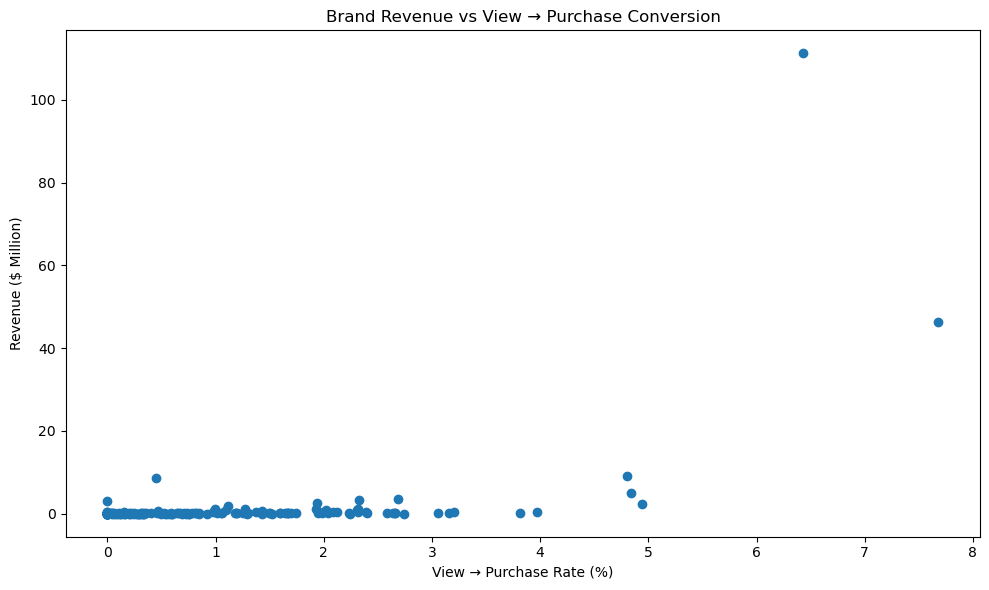

In [23]:
# Brand revenue vs conversion

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plot_data = brand[
    (brand["view_users"] >= 10_000) &
    (brand["revenue"] > 0)
].copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["view_to_purchase_rate"] * 100,
    plot_data["revenue"] / 1_000_000
)

plt.xlabel("View → Purchase Rate (%)")
plt.ylabel("Revenue ($ Million)")
plt.title(
    "Brand Revenue vs View → Purchase Conversion"
)

plt.tight_layout()
plt.show()

### How to Interpret the Chart

- High revenue + high conversion → strong performers
- High revenue + low conversion → optimization opportunity
- Low revenue + high conversion → potentially scalable performers
- Low revenue + low conversion → lower priority

These categories are used as an analytical framework; specific brands should be evaluated using both traffic scale and conversion before making recommendations.

In [24]:
#Lucente
brand[
    brand["brand"].str.lower() == "lucente"
]

,brand,view_users,cart_users,purchase_users,purchase_events,revenue,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
7,lucente,145492,0,0,11576,3123438.96,0.0,NaN,0.0


## 6. Price Band Analysis

Price-level performance is analyzed to understand how customer behavior and funnel conversion vary across different product price ranges.

The analysis uses the following price bands:

- \\$0
- \\$0–\\$50
- \\$50–\\$100
- \\$100–\\$250
- \\$250–\\$500
- \\$500–\\$1,000
- \\$1,000-\\$2,000
- \\$2,000+

The \\$0 band is kept separate because zero-price interactions were identified during data-quality analysis and should not be treated as a normal paid-product price segment.

In [25]:
# Load production price-band analysis

price_band = pd.read_csv(
    EDA_DIR / "price_band_analysis.csv"
)

print("Shape:", price_band.shape)

price_band

Shape: (8, 9)


,price_band,view_users,cart_users,purchase_users,purchase_events,revenue,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,$0,33053,91,0,0,0.00,0.002753,0.000000,0.000000
1,$0–$50,1175584,48428,24059,117067,3447265.29,0.041195,0.496799,0.020466
2,$50–$100,1111320,41437,21722,92298,6725620.63,0.037286,0.524217,0.019546
3,$100–$250,1694277,143893,85791,249282,41741415.95,0.084929,0.596214,0.050636
4,$250–$500,1310626,88903,49747,147764,50835116.53,0.067832,0.559565,0.037957
5,"$500–$1,000",904561,51500,28197,86960,62920782.03,0.056934,0.547515,0.031172
6,"$1,000–$2,000",593313,28894,15581,48377,62009383.86,0.048699,0.539247,0.026261
7,"$2,000+",109260,656,257,1025,2253628.34,0.006004,0.391768,0.002352


In [26]:
#Production validation
print("Duplicate price bands:",
      price_band["price_band"].duplicated().sum())

print("Missing price bands:",
      price_band["price_band"].isna().sum())

print("\nNegative metrics:")

print(
    price_band[
        [
            "view_users",
            "cart_users",
            "purchase_users",
            "purchase_events",
            "revenue"
        ]
    ].lt(0).sum()
)

print(
    "\nCart > View:",
    (
        price_band["cart_users"] >
        price_band["view_users"]
    ).sum()
)

print(
    "Purchase > Cart:",
    (
        price_band["purchase_users"] >
        price_band["cart_users"]
    ).sum()
)

Duplicate price bands: 0
Missing price bands: 0

Negative metrics:
view_users         0
cart_users         0
purchase_users     0
purchase_events    0
revenue            0
dtype: int64

Cart > View: 0
Purchase > Cart: 0


In [27]:
#Price-band funnel performance
price_band[
    [
        "price_band",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate"
    ]
]

,price_band,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,$0,33053,91,0,0.002753,0.000000,0.000000
1,$0–$50,1175584,48428,24059,0.041195,0.496799,0.020466
2,$50–$100,1111320,41437,21722,0.037286,0.524217,0.019546
3,$100–$250,1694277,143893,85791,0.084929,0.596214,0.050636
4,$250–$500,1310626,88903,49747,0.067832,0.559565,0.037957
5,"$500–$1,000",904561,51500,28197,0.056934,0.547515,0.031172
6,"$1,000–$2,000",593313,28894,15581,0.048699,0.539247,0.026261
7,"$2,000+",109260,656,257,0.006004,0.391768,0.002352


In [28]:
#Revenue by price band
price_band.sort_values(
    "revenue",
    ascending=False
)[
    [
        "price_band",
        "view_users",
        "purchase_users",
        "purchase_events",
        "revenue",
        "view_to_purchase_rate"
    ]
]

,price_band,view_users,purchase_users,purchase_events,revenue,view_to_purchase_rate
5,"$500–$1,000",904561,28197,86960,62920782.03,0.031172
6,"$1,000–$2,000",593313,15581,48377,62009383.86,0.026261
4,$250–$500,1310626,49747,147764,50835116.53,0.037957
3,$100–$250,1694277,85791,249282,41741415.95,0.050636
2,$50–$100,1111320,21722,92298,6725620.63,0.019546
1,$0–$50,1175584,24059,117067,3447265.29,0.020466
7,"$2,000+",109260,257,1025,2253628.34,0.002352
0,$0,33053,0,0,0.00,0.000000


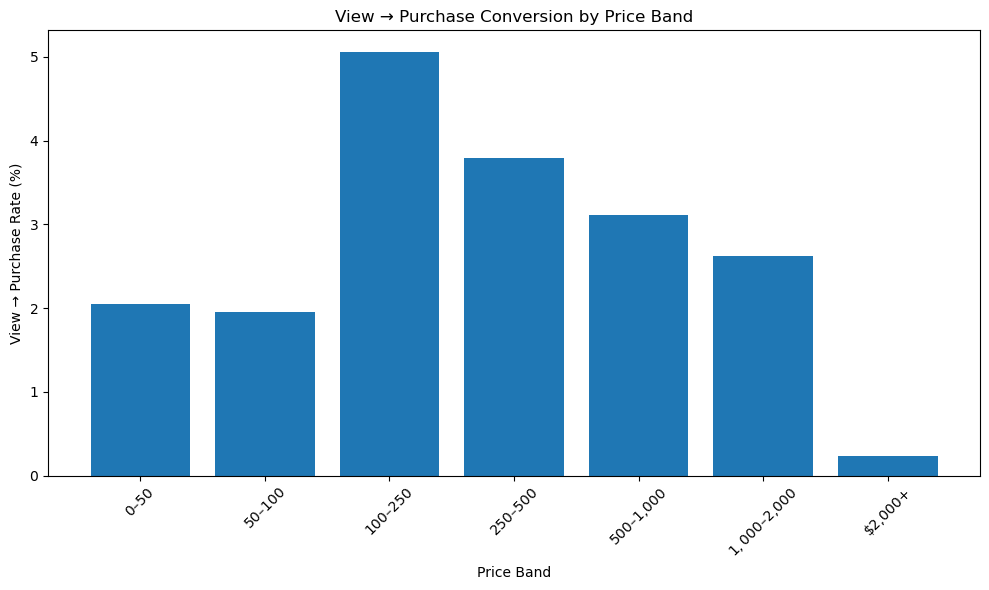

In [29]:
#Conversion by price band
import matplotlib.pyplot as plt

plot_data = price_band[
    price_band["price_band"] != "$0"
].copy()

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["price_band"],
    plot_data["view_to_purchase_rate"] * 100
)

plt.xlabel("Price Band")
plt.ylabel("View → Purchase Rate (%)")
plt.title(
    "View → Purchase Conversion by Price Band"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

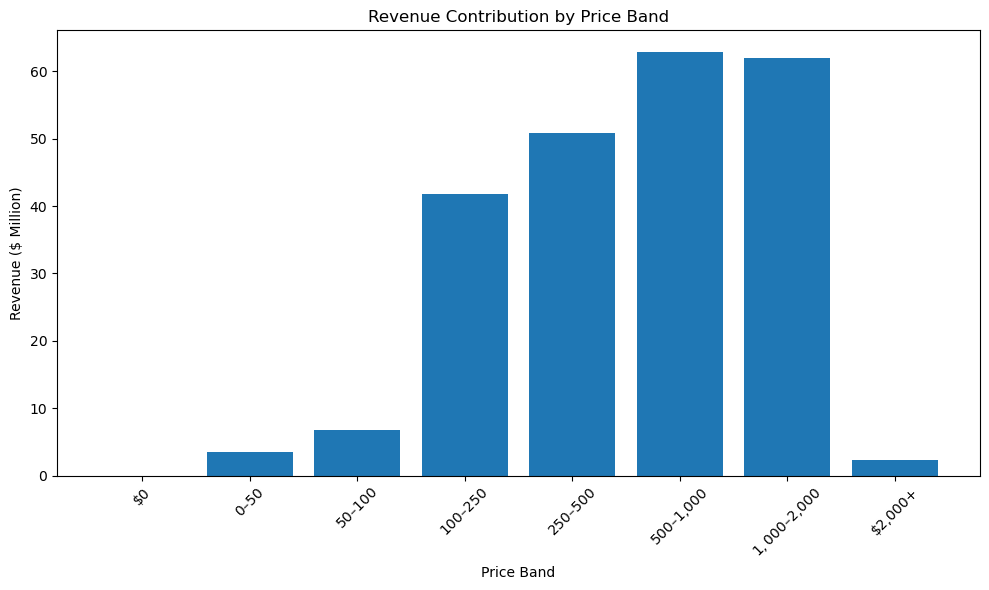

In [30]:
#Revenue by price band
plt.figure(figsize=(10, 6))

plt.bar(
    price_band["price_band"],
    price_band["revenue"] / 1_000_000
)

plt.xlabel("Price Band")
plt.ylabel("Revenue ($ Million)")
plt.title(
    "Revenue Contribution by Price Band"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Zero-Price Interaction Analysis

Zero-price records were retained because they are observed records in the
source dataset and were not identified as invalid during data-quality
validation.

They are analyzed separately from normal paid-price bands to avoid
distorting price-based conversion and revenue analysis.

In [31]:
price_band[
    price_band["price_band"] == "$0"
]

,price_band,view_users,cart_users,purchase_users,purchase_events,revenue,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,$0,33053,91,0,0,0.0,0.002753,0.0,0.0


In [32]:
#Identify the weakest high-value segment
high_value = price_band[
    price_band["price_band"].isin(
        [
            "$1,000–$2,000",
            "$2,000+"
        ]
    )
].sort_values(
    "view_to_purchase_rate"
)

high_value[
    [
        "price_band",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate",
        "revenue"
    ]
]

,price_band,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,revenue
7,"$2,000+",109260,656,257,0.006004,0.391768,0.002352,2253628.34
6,"$1,000–$2,000",593313,28894,15581,0.048699,0.539247,0.026261,62009383.86


## 7. Time Analysis

Time-based analysis is divided into two perspectives:

### 1. Funnel Cohort Analysis

Users are grouped according to the hour or day of their **first product view**.

This allows us to measure:

**First View → Eventual Add to Cart → Eventual Purchase**

Because the funnel is cohort-based, a user can view at one time and purchase later without causing time-bucket leakage.

### 2. Purchase Activity Analysis

Actual purchase events are analyzed according to the timestamp at which the purchase occurred.

This identifies when purchasing activity and revenue are highest.

> Time values are based on the UTC timestamps provided in the source dataset.

In [33]:
# Load production time analysis

time_analysis = pd.read_csv(
    EDA_DIR / "time_analysis.csv"
)

print("Shape:", time_analysis.shape)

time_analysis.head()

Shape: (62, 11)


,analysis_type,time_dimension,time_value,view_users,cart_users,purchase_users,purchase_events,revenue,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,funnel_cohort,hour,00,27066.0,1918.0,1010,4018,1132190.78,0.070864,0.526590,0.037316
1,funnel_cohort,hour,01,52409.0,3917.0,1981,7044,1832671.01,0.074739,0.505744,0.037799
2,funnel_cohort,hour,02,93969.0,8658.0,4804,19505,5744124.52,0.092137,0.554863,0.051123
3,funnel_cohort,hour,03,125799.0,13931.0,8276,33203,9844272.30,0.110740,0.594071,0.065787
4,funnel_cohort,hour,04,148246.0,17623.0,10658,43567,13126992.47,0.118877,0.604778,0.071894


In [34]:
#Separate the two analyses
funnel_time = time_analysis[
    time_analysis["analysis_type"] == "funnel_cohort"
].copy()

purchase_time = time_analysis[
    time_analysis["analysis_type"] == "purchase_activity"
].copy()

print("Funnel cohort rows:", len(funnel_time))
print("Purchase activity rows:", len(purchase_time))

Funnel cohort rows: 31
Purchase activity rows: 31


In [35]:
#Funnel conversion by hour
hourly_funnel = funnel_time[
    funnel_time["time_dimension"] == "hour"
].copy()

hourly_funnel[
    [
        "time_value",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate"
    ]
]

,time_value,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,00,27066.0,1918.0,1010,0.070864,0.526590,0.037316
1,01,52409.0,3917.0,1981,0.074739,0.505744,0.037799
2,02,93969.0,8658.0,4804,0.092137,0.554863,0.051123
3,03,125799.0,13931.0,8276,0.110740,0.594071,0.065787
4,04,148246.0,17623.0,10658,0.118877,0.604778,0.071894
5,05,161421.0,20045.0,12137,0.124178,0.605488,0.075188
6,06,172153.0,21696.0,13166,0.126027,0.606840,0.076478
7,07,177773.0,22315.0,13501,0.125525,0.605019,0.075945
8,08,178928.0,22407.0,13590,0.125229,0.606507,0.075952
9,09,173396.0,22045.0,13362,0.127137,0.606124,0.077061


In [36]:
#Best converting hours
best_hours = hourly_funnel[
    hourly_funnel["view_users"] >= 50_000
].sort_values(
    "view_to_purchase_rate",
    ascending=False
)

best_hours[
    [
        "time_value",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate"
    ]
].head(10)

,time_value,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
9,09,173396.0,22045.0,13362,0.127137,0.606124,0.077061
6,06,172153.0,21696.0,13166,0.126027,0.606840,0.076478
8,08,178928.0,22407.0,13590,0.125229,0.606507,0.075952
7,07,177773.0,22315.0,13501,0.125525,0.605019,0.075945
5,05,161421.0,20045.0,12137,0.124178,0.605488,0.075188
10,10,168582.0,20957.0,12579,0.124313,0.600229,0.074617
11,11,162632.0,19788.0,11722,0.121673,0.592379,0.072077
4,04,148246.0,17623.0,10658,0.118877,0.604778,0.071894
12,12,161297.0,18743.0,11024,0.116202,0.588166,0.068346
3,03,125799.0,13931.0,8276,0.110740,0.594071,0.065787


In [37]:
#Funnel conversion by day
daily_funnel = funnel_time[
    funnel_time["time_dimension"] == "day_of_week"
].copy()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

daily_funnel["day_order"] = (
    daily_funnel["time_value"]
    .map(
        {
            day: i
            for i, day in enumerate(day_order)
        }
    )
)

daily_funnel = daily_funnel.sort_values(
    "day_order"
)

daily_funnel[
    [
        "time_value",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate"
    ]
]

,time_value,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
24,Monday,340979.0,33271.0,19354,0.097575,0.581708,0.056760
25,Tuesday,561019.0,68758.0,40890,0.122559,0.594694,0.072885
26,Wednesday,509541.0,57022.0,34004,0.111909,0.596331,0.066735
27,Thursday,447195.0,47714.0,28071,0.106696,0.588318,0.062771
28,Friday,418129.0,50970.0,29415,0.121900,0.577104,0.070349
29,Saturday,372903.0,41137.0,23193,0.110316,0.563799,0.062196
30,Sunday,372364.0,37892.0,21561,0.101761,0.569012,0.057903


In [38]:
#Actual purchase activity by hour
hourly_purchase = purchase_time[
    purchase_time["time_dimension"] == "hour"
].copy()

hourly_purchase[
    [
        "time_value",
        "purchase_users",
        "purchase_events",
        "revenue"
    ]
]

,time_value,purchase_users,purchase_events,revenue
31,00,2197,2949,980317.85
32,01,4346,5526,1577532.87
33,02,10878,13968,3873027.44
34,03,22056,29632,8696837.45
35,04,30638,41143,12064072.73
36,05,35740,48068,14398553.24
37,06,38451,52002,15808753.76
38,07,39581,53404,16338607.12
39,08,40689,55195,17058580.92
40,09,40172,55182,17551669.73


In [39]:
hourly_purchase.sort_values(
    "revenue",
    ascending=False
)[
    [
        "time_value",
        "purchase_users",
        "purchase_events",
        "revenue"
    ]
].head(10)

,time_value,purchase_users,purchase_events,revenue
40,09,40172,55182,17551669.73
39,08,40689,55195,17058580.92
41,10,38244,51902,16361933.71
38,07,39581,53404,16338607.12
37,06,38451,52002,15808753.76
42,11,35383,47311,15082588.07
36,05,35740,48068,14398553.24
43,12,31663,41840,13238529.07
44,13,29924,39135,12363944.23
35,04,30638,41143,12064072.73


In [40]:
#Actual purchase activity by day
daily_purchase = purchase_time[
    purchase_time["time_dimension"] == "day_of_week"
].copy()

daily_purchase["day_order"] = (
    daily_purchase["time_value"]
    .map(
        {
            day: i
            for i, day in enumerate(day_order)
        }
    )
)

daily_purchase = daily_purchase.sort_values(
    "day_order"
)

daily_purchase[
    [
        "time_value",
        "purchase_users",
        "purchase_events",
        "revenue"
    ]
]

,time_value,purchase_users,purchase_events,revenue
55,Monday,63268,96059,30158469.47
56,Tuesday,75047,114502,36093986.02
57,Wednesday,77902,119154,37064086.24
58,Thursday,74131,113660,35850982.11
59,Friday,68058,102995,31729266.61
60,Saturday,64697,96175,29128868.23
61,Sunday,67556,100228,29907553.95


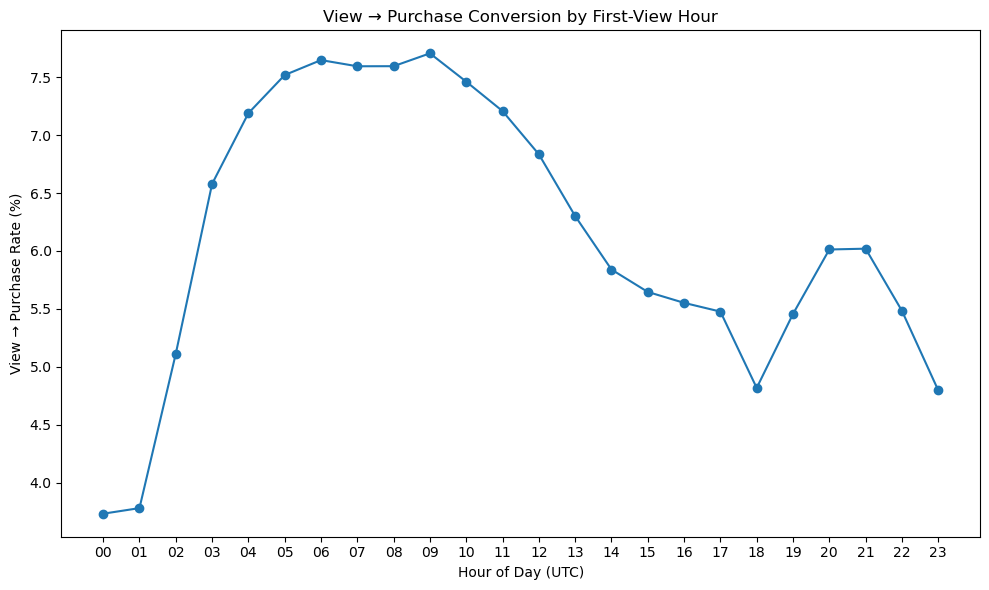

In [41]:
#Hourly conversion visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    hourly_funnel["time_value"],
    hourly_funnel["view_to_purchase_rate"] * 100,
    marker="o"
)

plt.xlabel("Hour of Day (UTC)")
plt.ylabel("View → Purchase Rate (%)")
plt.title(
    "View → Purchase Conversion by First-View Hour"
)

plt.tight_layout()
plt.show()

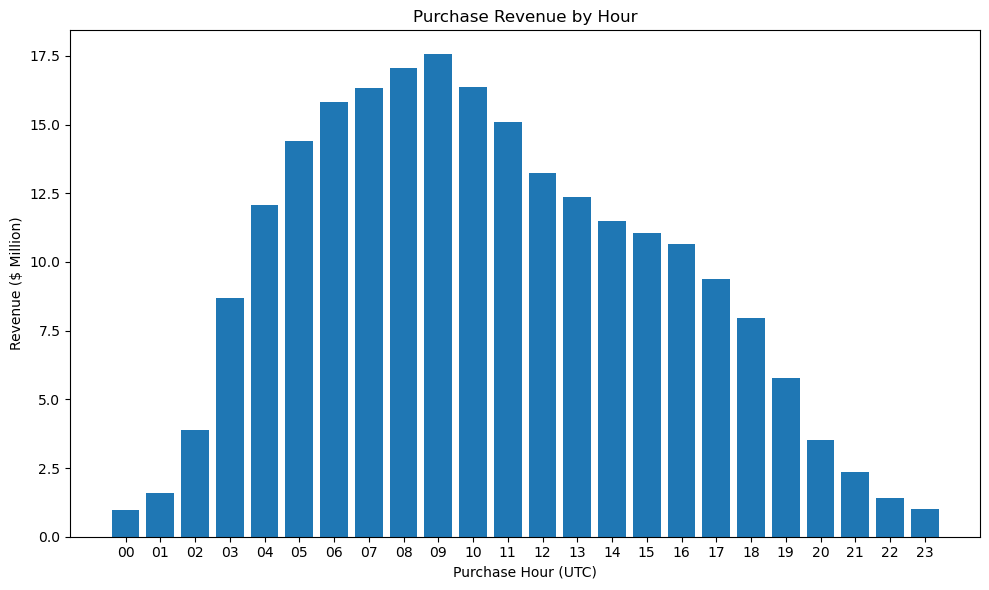

In [42]:
#Purchase revenue by hour
plt.figure(figsize=(10, 6))

plt.bar(
    hourly_purchase["time_value"],
    hourly_purchase["revenue"] / 1_000_000
)

plt.xlabel("Purchase Hour (UTC)")
plt.ylabel("Revenue ($ Million)")
plt.title(
    "Purchase Revenue by Hour"
)

plt.tight_layout()
plt.show()

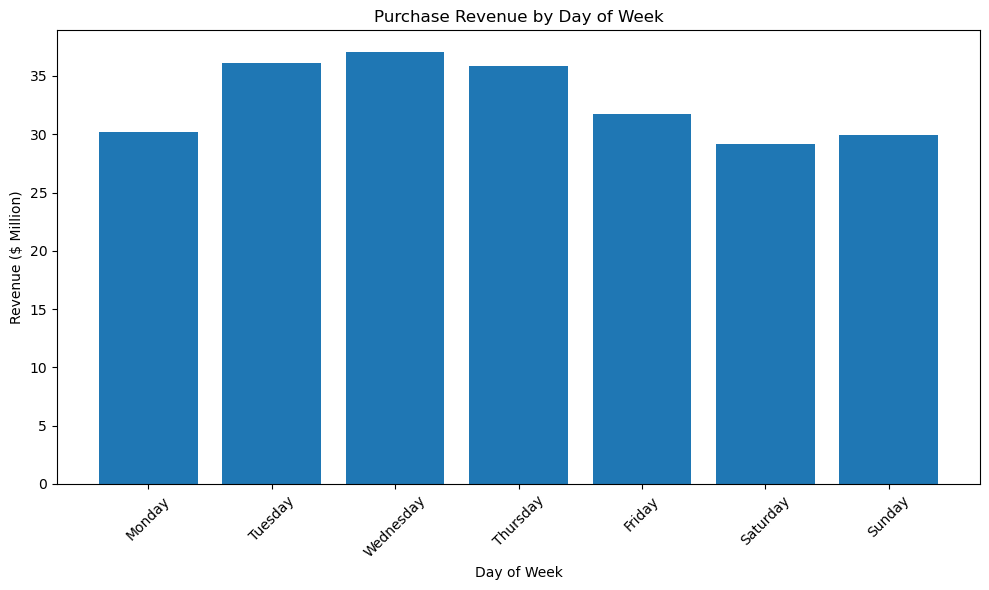

In [43]:
#Purchase revenue by day
plt.figure(figsize=(10, 6))

plt.bar(
    daily_purchase["time_value"],
    daily_purchase["revenue"] / 1_000_000
)

plt.xlabel("Day of Week")
plt.ylabel("Revenue ($ Million)")
plt.title(
    "Purchase Revenue by Day of Week"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Time Analysis Summary

Time analysis was used to understand when users are most likely to progress through the funnel and when actual purchasing activity generates the highest revenue.

Two perspectives were considered:

- **Funnel cohort analysis:** Users were grouped according to the hour and day of their first product view, and their subsequent cart and purchase behavior was evaluated.
- **Purchase activity analysis:** Actual purchase events, purchasing users, and revenue were analyzed according to the time of purchase.

The analysis uses the UTC timestamps provided in the source dataset.

# Cross-Analysis & Business Opportunity Identification

The previous analyses examined funnel performance across individual dimensions such as category, brand, price, and time.

This section combines these findings to identify business opportunities.

The objective is to move beyond descriptive statistics and determine:

- Which high-traffic segments have weak conversion?
- Which segments generate substantial revenue?
- Which segments combine strong traffic with poor purchase conversion?
- Which segments demonstrate strong conversion and could potentially be scaled?
- Which time periods combine strong conversion with high purchasing activity?

The final objective is to prioritize the most actionable opportunities for improving e-commerce conversion and revenue.

In [44]:
# Load analytical datasets

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

EDA_DIR = PROJECT_ROOT / "data" / "processed" / "eda"

category_analysis = pd.read_csv(
    EDA_DIR / "category_analysis.csv"
)

brand_analysis = pd.read_csv(
    EDA_DIR / "brand_analysis.csv"
)

price_band_analysis = pd.read_csv(
    EDA_DIR / "price_band_analysis.csv"
)

time_analysis = pd.read_csv(
    EDA_DIR / "time_analysis.csv"
)

print("Category:", category_analysis.shape)
print("Brand:", brand_analysis.shape)
print("Price:", price_band_analysis.shape)
print("Time:", time_analysis.shape)

Category: (127, 9)
Brand: (3445, 9)
Price: (8, 9)
Time: (62, 11)


### Cross-Analysis 1 — Identify high-traffic, low-conversion categories

In [45]:
# Category benchmarks

category_benchmark = {
    "median_view_users": category_analysis["view_users"].median(),
    "median_view_to_purchase_rate": category_analysis["view_to_purchase_rate"].median()
}

category_benchmark

{'median_view_users': 11564.0,
 'median_view_to_purchase_rate': 0.0065520065520065}

In [46]:
# High-traffic, low-conversion category opportunities

category_opportunities = category_analysis[
    (category_analysis["view_users"] >= category_benchmark["median_view_users"]) &
    (category_analysis["view_to_purchase_rate"] < category_benchmark["median_view_to_purchase_rate"])
].copy()

category_opportunities = category_opportunities.sort_values(
    "view_users",
    ascending=False
)

category_opportunities[
    [
        "category_code",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate",
        "revenue"
    ]
].head(20)

,category_code,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,revenue
18,apparel.shoes,126760,0,0,0.000000,NaN,0.000000,366486.97
38,apparel.shoes.keds,91620,0,0,0.000000,NaN,0.000000,188218.50
12,auto.accessories.player,80415,754,397,0.009376,0.526525,0.004937,523165.86
16,furniture.bedroom.bed,78982,482,234,0.006103,0.485477,0.002963,375758.69
60,apparel.costume,55708,0,0,0.000000,NaN,0.000000,46492.98
14,furniture.living_room.cabinet,53883,0,0,0.000000,NaN,0.000000,452398.40
20,electronics.audio.subwoofer,50036,214,103,0.004277,0.481308,0.002059,300022.08
11,furniture.living_room.sofa,45765,0,0,0.000000,NaN,0.000000,569565.81
58,accessories.bag,44780,304,144,0.006789,0.473684,0.003216,53155.53
66,kids.toys,34668,286,111,0.008250,0.388112,0.003202,35968.55


In [47]:
# High-traffic, high-conversion categories

category_stars = category_analysis[
    (category_analysis["view_users"] >= category_benchmark["median_view_users"]) &
    (category_analysis["view_to_purchase_rate"] >= category_benchmark["median_view_to_purchase_rate"])
].copy()

category_stars = category_stars.sort_values(
    "revenue",
    ascending=False
)

category_stars[
    [
        "category_code",
        "view_users",
        "purchase_users",
        "view_to_purchase_rate",
        "revenue"
    ]
].head(20)

,category_code,view_users,purchase_users,view_to_purchase_rate,revenue
0,electronics.smartphone,1300070,120283,0.092520,1.570339e+08
1,Unknown,1514526,25968,0.017146,2.292217e+07
2,computers.notebook,129207,3834,0.029673,8.978883e+06
3,electronics.video.tv,170044,8786,0.051669,8.422119e+06
4,electronics.clocks,211922,4883,0.023041,4.817089e+06
5,appliances.kitchen.washer,132028,5212,0.039476,4.658223e+06
6,appliances.kitchen.refrigerators,131602,3067,0.023305,3.830077e+06
7,electronics.audio.headphone,213948,11811,0.055205,3.538807e+06
8,appliances.environment.vacuum,119925,4869,0.040600,1.716425e+06
9,electronics.tablet,58730,2200,0.037460,1.610917e+06


### Cross-Analysis 2 — Revenue × Conversion

In [48]:
# Top revenue categories

top_revenue_categories = category_analysis.sort_values(
    "revenue",
    ascending=False
)

top_revenue_categories[
    [
        "category_code",
        "view_users",
        "purchase_users",
        "view_to_purchase_rate",
        "purchase_events",
        "revenue"
    ]
].head(15)

,category_code,view_users,purchase_users,view_to_purchase_rate,purchase_events,revenue
0,electronics.smartphone,1300070,120283,0.092520,337979,1.570339e+08
1,Unknown,1514526,25968,0.017146,173411,2.292217e+07
2,computers.notebook,129207,3834,0.029673,15588,8.978883e+06
3,electronics.video.tv,170044,8786,0.051669,21561,8.422119e+06
4,electronics.clocks,211922,4883,0.023041,17903,4.817089e+06
5,appliances.kitchen.washer,132028,5212,0.039476,16146,4.658223e+06
6,appliances.kitchen.refrigerators,131602,3067,0.023305,11218,3.830077e+06
7,electronics.audio.headphone,213948,11811,0.055205,30501,3.538807e+06
8,appliances.environment.vacuum,119925,4869,0.040600,12378,1.716425e+06
9,electronics.tablet,58730,2200,0.037460,5602,1.610917e+06


In [49]:
#Is its revenue driven by traffic, conversion, or both?
smartphone = category_analysis[
    category_analysis["category_code"] == "electronics.smartphone"
]

smartphone[
    [
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate",
        "purchase_events",
        "revenue"
    ]
]

,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events,revenue
0,1300070,198021,120283,0.152316,0.607425,0.09252,337979,1.570339e+08


### Cross-Analysis 3 — Brand

In [50]:
#Removing Unknowns
known_brands = brand_analysis[
    brand_analysis["brand"] != "Unknown"
].copy()

In [51]:
#High-revenue brands
top_revenue_brands = known_brands.sort_values(
    "revenue",
    ascending=False
)

top_revenue_brands[
    [
        "brand",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate",
        "purchase_events",
        "revenue"
    ]
].head(20)

,brand,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,purchase_events,revenue
0,apple,729319,81931,46884,0.112339,0.572238,0.064285,142858,1.111995e+08
1,samsung,935464,119305,71858,0.127536,0.602305,0.076815,172878,4.640204e+07
2,xiaomi,470832,43364,22624,0.092101,0.521723,0.048051,56609,9.192640e+06
4,huawei,234061,19014,11334,0.081235,0.596087,0.048423,23499,4.883105e+06
5,acer,87586,4744,2353,0.054164,0.495995,0.026865,6880,3.575716e+06
6,lg,145762,6973,3389,0.047838,0.486017,0.023250,8725,3.387361e+06
7,lucente,145492,0,0,0.000000,NaN,0.000000,11576,3.123439e+06
8,sony,122111,5127,2367,0.041986,0.461673,0.019384,6729,2.478197e+06
9,oppo,114818,9091,5671,0.079177,0.623804,0.049391,10887,2.412034e+06
10,lenovo,69962,1533,777,0.021912,0.506849,0.011106,4578,1.752639e+06


In [52]:
#Brands with enough traffic but weak conversion
brand_view_threshold = known_brands["view_users"].quantile(0.75)
brand_conversion_median = known_brands["view_to_purchase_rate"].median()

brand_opportunities = known_brands[
    (known_brands["view_users"] >= brand_view_threshold) &
    (known_brands["view_to_purchase_rate"] < brand_conversion_median)
].copy()

brand_opportunities = brand_opportunities.sort_values(
    "view_users",
    ascending=False
)

brand_opportunities[
    [
        "brand",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_purchase_rate",
        "revenue"
    ]
].head(20)

,brand,view_users,cart_users,purchase_users,view_to_purchase_rate,revenue


### Cross-Analysis 4 — Price

In [53]:
# Exclude zero-price interactions from normal price comparison

paid_price = price_band_analysis[
    price_band_analysis["price_band"] != "$0"
].copy()

paid_price.sort_values(
    "view_to_purchase_rate",
    ascending=False
)[
    [
        "price_band",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate",
        "revenue"
    ]
]

,price_band,view_users,cart_users,purchase_users,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,revenue
3,$100–$250,1694277,143893,85791,0.084929,0.596214,0.050636,41741415.95
4,$250–$500,1310626,88903,49747,0.067832,0.559565,0.037957,50835116.53
5,"$500–$1,000",904561,51500,28197,0.056934,0.547515,0.031172,62920782.03
6,"$1,000–$2,000",593313,28894,15581,0.048699,0.539247,0.026261,62009383.86
1,$0–$50,1175584,48428,24059,0.041195,0.496799,0.020466,3447265.29
2,$50–$100,1111320,41437,21722,0.037286,0.524217,0.019546,6725620.63
7,"$2,000+",109260,656,257,0.006004,0.391768,0.002352,2253628.34


In [54]:
#Revenue leaders
paid_price.sort_values(
    "revenue",
    ascending=False
)[
    [
        "price_band",
        "view_users",
        "purchase_users",
        "view_to_purchase_rate",
        "purchase_events",
        "revenue"
    ]
]

,price_band,view_users,purchase_users,view_to_purchase_rate,purchase_events,revenue
5,"$500–$1,000",904561,28197,0.031172,86960,62920782.03
6,"$1,000–$2,000",593313,15581,0.026261,48377,62009383.86
4,$250–$500,1310626,49747,0.037957,147764,50835116.53
3,$100–$250,1694277,85791,0.050636,249282,41741415.95
2,$50–$100,1111320,21722,0.019546,92298,6725620.63
1,$0–$50,1175584,24059,0.020466,117067,3447265.29
7,"$2,000+",109260,257,0.002352,1025,2253628.34


### Cross-Analysis 5 — Time

In [55]:
# Funnel cohort analysis

funnel_time = time_analysis[
    time_analysis["analysis_type"] == "funnel_cohort"
].copy()

# Actual purchase activity

purchase_time = time_analysis[
    time_analysis["analysis_type"] == "purchase_activity"
].copy()

In [56]:
#Best first-view hours
best_conversion_hours = funnel_time[
    funnel_time["time_dimension"] == "hour"
].sort_values(
    "view_to_purchase_rate",
    ascending=False
)

best_conversion_hours[
    [
        "time_value",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_purchase_rate"
    ]
].head(10)

,time_value,view_users,cart_users,purchase_users,view_to_purchase_rate
9,09,173396.0,22045.0,13362,0.077061
6,06,172153.0,21696.0,13166,0.076478
8,08,178928.0,22407.0,13590,0.075952
7,07,177773.0,22315.0,13501,0.075945
5,05,161421.0,20045.0,12137,0.075188
10,10,168582.0,20957.0,12579,0.074617
11,11,162632.0,19788.0,11722,0.072077
4,04,148246.0,17623.0,10658,0.071894
12,12,161297.0,18743.0,11024,0.068346
3,03,125799.0,13931.0,8276,0.065787


In [57]:
#Highest purchase-revenue hours
purchase_time_hours = purchase_time[
    purchase_time["time_dimension"] == "hour"
].sort_values(
    "revenue",
    ascending=False
)

purchase_time_hours[
    [
        "time_value",
        "purchase_users",
        "purchase_events",
        "revenue"
    ]
].head(10)

,time_value,purchase_users,purchase_events,revenue
40,09,40172,55182,17551669.73
39,08,40689,55195,17058580.92
41,10,38244,51902,16361933.71
38,07,39581,53404,16338607.12
37,06,38451,52002,15808753.76
42,11,35383,47311,15082588.07
36,05,35740,48068,14398553.24
43,12,31663,41840,13238529.07
44,13,29924,39135,12363944.23
35,04,30638,41143,12064072.73


In [58]:
#Day-level cross-analysis
best_conversion_days = funnel_time[
    funnel_time["time_dimension"] == "day_of_week"
].sort_values(
    "view_to_purchase_rate",
    ascending=False
)

best_conversion_days[
    [
        "time_value",
        "view_users",
        "cart_users",
        "purchase_users",
        "view_to_purchase_rate"
    ]
]

,time_value,view_users,cart_users,purchase_users,view_to_purchase_rate
25,Tuesday,561019.0,68758.0,40890,0.072885
28,Friday,418129.0,50970.0,29415,0.070349
26,Wednesday,509541.0,57022.0,34004,0.066735
27,Thursday,447195.0,47714.0,28071,0.062771
29,Saturday,372903.0,41137.0,23193,0.062196
30,Sunday,372364.0,37892.0,21561,0.057903
24,Monday,340979.0,33271.0,19354,0.056760


In [59]:
#Day-level revenue
purchase_time_days = purchase_time[
    purchase_time["time_dimension"] == "day_of_week"
].sort_values(
    "revenue",
    ascending=False
)

purchase_time_days[
    [
        "time_value",
        "purchase_users",
        "purchase_events",
        "revenue"
    ]
]

,time_value,purchase_users,purchase_events,revenue
57,Wednesday,77902,119154,37064086.24
56,Tuesday,75047,114502,36093986.02
58,Thursday,74131,113660,35850982.11
59,Friday,68058,102995,31729266.61
55,Monday,63268,96059,30158469.47
61,Sunday,67556,100228,29907553.95
60,Saturday,64697,96175,29128868.23


# Final Business Insights

The analysis combines overall funnel performance with category, brand, price-band, and time-based segmentation to identify the most important business opportunities.

## 1. The largest funnel bottleneck is View → Add to Cart

The overall funnel shows that approximately **11.14% of viewed users add a product to cart**, while approximately **58.35% of cart users proceed to a qualifying purchase**.

This indicates that the primary funnel constraint occurs before the cart stage rather than between cart and purchase.

**Business implication:** Improving product-page engagement, product information, pricing visibility, reviews, offers, and add-to-cart experience should be a higher priority than focusing exclusively on checkout optimization.

---

## 2. Smartphones are the strongest combination of scale, conversion, and revenue

The `electronics.smartphone` category generated approximately **$157.0M in revenue** and recorded approximately **1.30M viewing users**.

Its View → Purchase conversion rate was approximately **9.25%**, substantially stronger than the overall funnel conversion rate.

**Business implication:** Smartphones represent a high-value category where the business already has strong demand and conversion. Successful merchandising and promotional strategies in this category could potentially be replicated across other high-traffic categories.

---

## 3. Several high-traffic categories have substantially weaker conversion

The category analysis identifies segments with significant traffic but relatively weak View → Purchase conversion.

These segments are important because they receive enough customer attention to create meaningful improvement opportunities.

**Business implication:** Rather than optimizing every category equally, the business should prioritize high-traffic categories with below-benchmark conversion because even a modest improvement in conversion could generate a meaningful increase in purchases.

---

## 4. Revenue and conversion are not the same thing

The price-band analysis shows that the **\\$100–\\$250** segment has the highest View → Purchase conversion at approximately **5.06%**.

However, the **\\$500–\\$1,000** and **\\$1,000–\\$2,000** segments generate substantially more revenue, with approximately **\$62.9M** and **\$62.0M** respectively.

**Business implication:** The company should not optimize exclusively for conversion rate. A segment with lower conversion can still be strategically important when its revenue contribution is high.

---

## 5. High-priced products show a major conversion weakness

The **\$2,000+** price band has approximately **0.24% View → Purchase conversion**, considerably lower than the other paid price bands.

Although this segment contributes less overall revenue than the major mid-price bands, its weak conversion indicates a potential barrier in the purchase journey.

**Business implication:** High-priced products may benefit from stronger trust signals, detailed product information, reviews, financing/payment options, warranties, or targeted promotions.

These should be treated as hypotheses for further investigation rather than proven causes.

---

## 6. Revenue is highly concentrated among leading brands

The brand analysis shows substantial revenue concentration among a small number of major brands.

**Apple** generated approximately **\$111.2M**, followed by **Samsung** at approximately **\$46.4M**, with Xiaomi generating approximately **\$9.2M**.

**Business implication:** These brands represent major revenue drivers and should receive careful inventory, merchandising, and promotional attention. Their customer journeys can also be studied to identify practices associated with stronger conversion.

---

## 7. Conversion and purchasing activity peak at different times

The time analysis shows that **Tuesday has the highest View → Purchase conversion among the day-of-week cohorts at approximately 7.29%**.

However, actual purchase activity generates the highest daily revenue on **Wednesday**, at approximately **\$37.06M**.

At the hourly level, approximately **09:00 UTC** has the highest View → Purchase conversion at around **7.71%**, while the highest hourly purchase revenue is also observed around **09:00 UTC**, at approximately **\$17.55M**.

**Business implication:** Marketing and promotional decisions should consider both conversion efficiency and revenue volume. The time period with the highest conversion rate is not necessarily the same as the period with the highest business impact.

---

# Priority Business Recommendations

Based on the analysis, the recommended priorities are:

### Priority 1 — Improve View → Cart conversion

The largest funnel drop occurs between product viewing and cart addition.

Focus areas should include:

- Product-page optimization
- Clear pricing and offers
- Product reviews and ratings
- Product information
- Stronger calls to action
- Better visibility of delivery/return information

### Priority 2 — Optimize high-traffic, low-conversion categories

Prioritize categories with substantial traffic but below-benchmark conversion rather than attempting to optimize every category equally.

### Priority 3 — Protect and scale high-performing categories

Categories such as smartphones demonstrate that high traffic and strong conversion can coexist. Successful merchandising and promotional practices should be investigated for potential replication.

### Priority 4 — Investigate high-price conversion barriers

The extremely low conversion of the \$2,000+ price segment warrants further investigation into customer trust, pricing, payment flexibility, and product information.

### Priority 5 — Use time-based performance for campaign planning

High-performing conversion periods and high-revenue purchasing periods can be used to guide campaign timing, promotional activity, and operational readiness.

---

# Overall Conclusion

The analysis indicates that the largest opportunity is not simply generating more traffic. The business already receives substantial product-view activity.

The primary opportunity is to **convert existing traffic more effectively**, particularly at the View → Cart stage, while prioritizing high-traffic categories and understanding differences across price segments, brands, and time periods.

The combination of **funnel conversion, traffic scale, and revenue contribution** provides a stronger basis for business decisions than any single KPI alone.